In [1]:
from crawl4ai import AsyncWebCrawler, CrawlerRunConfig, BrowserConfig

In [2]:
MAX_URLS_PER_DOMAIN = 30
MAX_URLS_PER_DOMAIN_DEEP = 50

In [3]:
from urllib.parse import urlparse, urlunparse
def sanitize_url(url: str) -> str:
    url = url.strip()
    if not url.startswith(("http://", "https://")):
        url = "https://" + url
    parsed = urlparse(url)
    netloc = parsed.netloc.lower()
    if netloc.startswith("www."):
        netloc = netloc[4:]
    clean = parsed._replace(
        scheme=parsed.scheme.lower(),
        netloc=netloc,
        path="",
        params="",
        query="",
        fragment="",
    )
    return urlunparse(clean)


In [4]:
import requests

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Referer": "https://www.shl.com/"
}

import requests




r = requests.get(
    "https://tcp-us-prod-rnd.shl.com/voiceRater/shl-ai-hiring/shl_product_catalog.json",
    headers=headers
)

print(r.status_code)


200


In [5]:
print(r.headers["Content-Type"])

application/json


In [6]:
text = r.text.replace(
    '"Microsoft \n    365 (New)"',
    '"Microsoft 365 (New)"'
)

import json
data = json.loads(text)

In [7]:
unique_keys = set()

for assessment in data:
    unique_keys.update(assessment["keys"])

print(unique_keys)

{'Biodata & Situational Judgment', 'Ability & Aptitude', 'Assessment Exercises', 'Simulations', 'Knowledge & Skills', 'Competencies', 'Personality & Behavior', 'Development & 360'}


In [8]:
from typing import TypedDict, Optional, List, Dict


class Metadata(TypedDict, total=False):
    category: List[str]
    job_levels: List[str]
    languages: List[str]
    remote: Optional[bool]
    adaptive: Optional[bool]
    duration_max: Optional[int]


class Entities(TypedDict, total=False):
    assessments: List[str]

class RetrievedDocument(TypedDict):
    entity_id: str
    name: str
    link: str
    description: str
    score: float
    source: str   # "bm25", "vector", "rrf"

class AgentState(TypedDict):

    # Input
    query: str

    # Query Understanding
    off_topic: bool
    needs_clarification: bool
    clarification_question: Optional[str]
   

    # Parsed Query
    metadata: Metadata
    entities: Entities
    semantic_query: str

    # Retrieval
    bm25_results: List[RetrievedDocument]
    vector_results: List[RetrievedDocument]
    fused_results: List[RetrievedDocument]
    reranked_results: List[RetrievedDocument]

    # Output
    final_answer: str

In [9]:
from langgraph.graph import StateGraph
builder=StateGraph(AgentState)

In [10]:
def QueryUnderstandingFunction(state: AgentState):
    """
    Intent: Query Metadata
    Description: The user is asking for metadata about assessments, such as category, job level, language, etc.
    """
    pass

def metaDataFiltering(state:AgentState):
    """This Provides us the Meta Data Filtering or Filter which we have to Do"""
    pass

def BM25Result(state:AgentState):
    """This Provides us the  BM25 Results which will be searched on the basis of MetaData"""
    pass



def clarfying_question(state:AgentState):
    """Human In the loop here if something is missing in entity and all """
    pass

def Sementic_Search(state:AgentState):
    """Provides me the sementic search query ging the sementic search combined with the vector_search"""
    pass

def RRF(state:AgentState):
    """Merge the BM25 and vector Search Answer"""
    pass
def Reranker(state:AgentState):
    """Reranker"""
    pass

def final_answer(state:AgentState):
    """final_answer"""
    pass



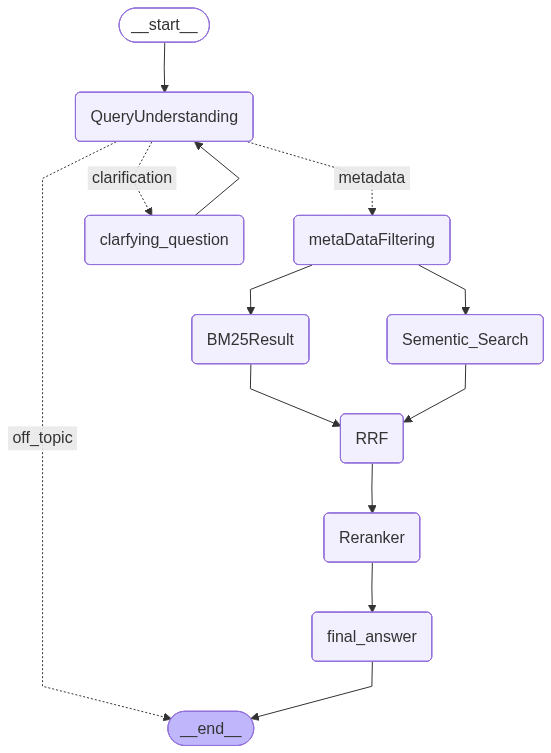

In [11]:
from langgraph.graph import END,START

builder.add_node("QueryUnderstanding",QueryUnderstandingFunction)
builder.add_node("metaDataFiltering",metaDataFiltering)
builder.add_node("BM25Result",BM25Result)
builder.add_node("clarfying_question",clarfying_question)
builder.add_node("Sementic_Search",Sementic_Search)
builder.add_node("RRF",RRF)
builder.add_node("Reranker",Reranker)
builder.add_node("final_answer",final_answer)


builder.add_edge(START,"QueryUnderstanding")
builder.add_conditional_edges(
    "QueryUnderstanding",
    lambda state: (
        "off_topic" if state["off_topic"]
        else "clarification" if state["needs_clarification"]
        else "metadata"
    ),
    {
        "off_topic": END,
        "clarification": "clarfying_question",
        "metadata": "metaDataFiltering",
    },
)

builder.add_edge("clarfying_question","QueryUnderstanding")
builder.add_edge("metaDataFiltering","BM25Result")
builder.add_edge("metaDataFiltering","Sementic_Search")
builder.add_edge("BM25Result","RRF")
builder.add_edge("Sementic_Search","RRF")
builder.add_edge("RRF","Reranker")
builder.add_edge("Reranker","final_answer")

graph=builder.compile()

builder.compile()


